In [20]:
from matplotlib import pyplot as plt
import warnings
warnings.filterwarnings('ignore', category=UserWarning, module='sklearn')
import pandas as pd
import joblib
from utils import DataProcessor

In [21]:
data = DataProcessor("../../hyper_wheat_ds_ch_norm_prep_mode=dai.csv").split_data()

with open('../../../Models/lightgbm.pkl', 'rb') as f:
    model = joblib.load(f)

In [22]:
import lime.lime_tabular
explainer = lime.lime_tabular.LimeTabularExplainer( training_data=data.x_train.values,
                                                    feature_names=data.x.columns,
                                                    class_names=['0', '1'],
                                                    discretize_continuous=False)

Выбираем номер объекта

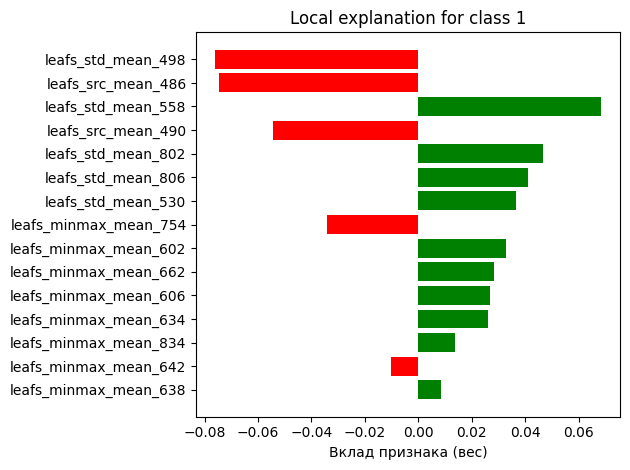

In [23]:
object = 2
exp = explainer.explain_instance(data.x_test.iloc[object].values, model.predict_proba, num_features=15)


exp.as_pyplot_figure()
plt.xlabel('Вклад признака (вес)')
plt.tight_layout()
plt.show()

In [24]:
feature_weights = pd.DataFrame(exp.as_list(), columns=['Признак', 'Вес признака'])
feature_values = data.x_test.iloc[object][feature_weights['Признак']].values
feature_weights['Значение признака'] = feature_values
print(feature_weights)

                  Признак  Вес признака  Значение признака
0      leafs_std_mean_498     -0.075892          -0.164509
1      leafs_src_mean_486     -0.074411          -0.465918
2      leafs_std_mean_558      0.068298           0.168320
3      leafs_src_mean_490     -0.054295          -0.520527
4      leafs_std_mean_802      0.046587           0.317397
5      leafs_std_mean_806      0.040938           0.412151
6      leafs_std_mean_530      0.036431          -0.366370
7   leafs_minmax_mean_754     -0.034237           0.872690
8   leafs_minmax_mean_602      0.032870           0.070515
9   leafs_minmax_mean_662      0.028425           0.007862
10  leafs_minmax_mean_606      0.026775           0.066611
11  leafs_minmax_mean_634      0.025973           0.041356
12  leafs_minmax_mean_834      0.013721           0.915038
13  leafs_minmax_mean_642     -0.010334           0.034304
14  leafs_minmax_mean_638      0.008439           0.038395


In [25]:
from IPython import display

display.HTML(exp.as_html(show_table=True))

In [26]:
explainer = lime.lime_tabular.LimeTabularExplainer(training_data=data.x_train.values,
                                                    feature_names=data.x.columns,
                                                    class_names=['0', '1'],
                                                    discretize_continuous=True)

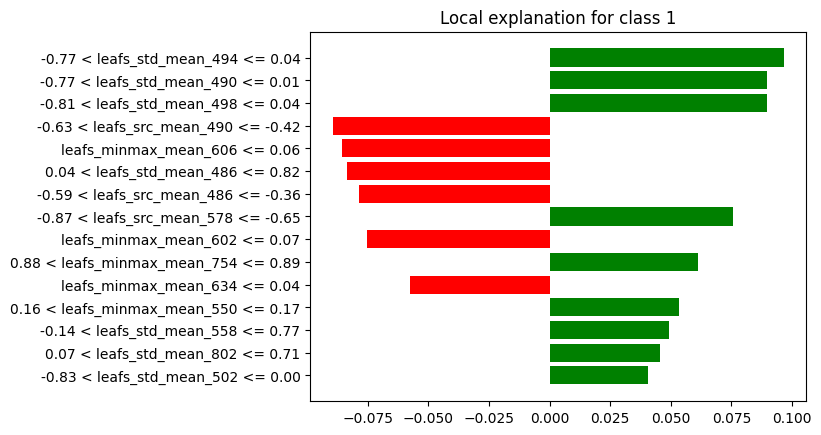

In [28]:
num_features = 15
exp = explainer.explain_instance(data.x_test.iloc[object].values, model.predict_proba, num_features=num_features)
exp.as_pyplot_figure()
plt.show()

In [29]:
exp.save_to_file('lime_explanation.html')

In [30]:
df = pd.DataFrame(exp.as_list(), columns=['Границы признака', 'Вес признака'])
print(df)

                        Границы признака  Вес признака
0     -0.77 < leafs_std_mean_494 <= 0.04      0.096514
1     -0.77 < leafs_std_mean_490 <= 0.01      0.089701
2     -0.81 < leafs_std_mean_498 <= 0.04      0.089580
3    -0.63 < leafs_src_mean_490 <= -0.42     -0.089542
4          leafs_minmax_mean_606 <= 0.06     -0.085773
5      0.04 < leafs_std_mean_486 <= 0.82     -0.083431
6    -0.59 < leafs_src_mean_486 <= -0.36     -0.078462
7    -0.87 < leafs_src_mean_578 <= -0.65      0.075597
8          leafs_minmax_mean_602 <= 0.07     -0.075216
9   0.88 < leafs_minmax_mean_754 <= 0.89      0.061341
10         leafs_minmax_mean_634 <= 0.04     -0.057500
11  0.16 < leafs_minmax_mean_550 <= 0.17      0.053446
12    -0.14 < leafs_std_mean_558 <= 0.77      0.049182
13     0.07 < leafs_std_mean_802 <= 0.71      0.045453
14    -0.83 < leafs_std_mean_502 <= 0.00      0.040659
